# Feature selection: filter, wrapper, embedded

### Plant columns that should be thrown away, then see who throws them away

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The three families of feature selection and what separates them, how to write mutual information and recursive feature elimination from scratch, which methods remove pure noise, which methods remove duplicated information, and what the wrapper costs in seconds |
| **You should already know** | [Logistic regression](../../03-classification/01-logistic-regression/), [random forests](../../04-ensembles/02-random-forest/), [cross-validation](../../01-foundations/04-cross-validation/) |
| **Dataset** | Breast Cancer Wisconsin (569 × 30), with columns of known-worthless noise and known-duplicate information planted into it |
| **Runtime** | One to two minutes on a laptop CPU |
| **Next** | [07-01 The perceptron](../../07-neural-networks/01-the-perceptron/) |

---

## 1. The idea

Feature selection is choosing a subset of your columns and throwing the rest
away. The reasons are model speed, model size, and the fact that a column
carrying nothing can still be fitted to, which is [overfitting](../../01-foundations/03-overfitting-and-underfitting/)
with extra steps.

Three families, and the difference between them is how much they know about the
model that will eventually be trained.

| family | what it does | knows about the model |
|---|---|---|
| **Filter** | Scores each column against the target on its own, keeps the best | nothing |
| **Wrapper** | Trains the model on subsets and keeps the subset that scores best | everything, and pays for it |
| **Embedded** | The model selects while it fits, through L1 or through split counts | it is the model |

Most write-ups stop there, with a sentence about filters being cheap and wrappers
being expensive. That sentence is true and nearly useless, because it does not
tell you what any of them will actually do to your data.

So this notebook plants the answer key. Two kinds of column go into a real
dataset:

**Irrelevant columns.** Pure noise, generated from random numbers, with no
relationship to the target or to anything else. Any method worth using must throw
all of them away.

**Redundant columns.** Copies of real columns with a little noise added. Each one
is individually predictive, so a method that scores columns one at a time will
love it, and keeping both the copy and the original spends budget on information
already in hand.

The textbook prediction is that filters handle the first and fail the second,
because scoring a column on its own cannot notice that another column already
says the same thing. Section 5 tests that prediction rather than repeating it.

In [1]:
import sys
import pathlib
import time
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, evaluate, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X_real, y = datasets.breast_cancer()
real_columns = list(X_real.columns)

# copy=True because pandas 3.0 hands back a read-only view here, and
# fill_diagonal writes in place.
correlation = X_real.corr().abs().to_numpy(copy=True)
np.fill_diagonal(correlation, 0.0)
print(f"{X_real.shape[0]} rows, {X_real.shape[1]} real columns, "
      f"{y.nunique()} classes")
print(f"largest absolute correlation between two real columns: {correlation.max():.4f}")
print(f"pairs of real columns correlated above 0.90: "
      f"{int((np.triu(correlation, 1) > 0.90).sum())}")

569 rows, 30 real columns, 2 classes
largest absolute correlation between two real columns: 0.9979
pairs of real columns correlated above 0.90: 21


Note that last number before going any further. This dataset already contains
duplicated information: the real columns are a small set of nucleus measurements
each reported several ways, as a mean, a standard error and a worst case.
Redundancy is not something being introduced here for the first time, only
something being made measurable.

### The planted columns

In [2]:
N_NOISE = 8
N_REDUNDANT = 6
COPY_NOISE = 0.25          # noise added to each copy, in units of the column's own sd

rng = np.random.default_rng(SEED)
n = len(X_real)

X = X_real.copy()

# Eight columns containing nothing. They differ in how many distinct values they
# take, because 12-02 found that impurity importance is sensitive to exactly that.
noise_columns = []
X["noise_coin"] = rng.integers(0, 2, n).astype(float)
X["noise_dice"] = rng.integers(1, 7, n).astype(float)
X["noise_id"] = rng.integers(0, 500, n).astype(float)
noise_columns += ["noise_coin", "noise_dice", "noise_id"]
for i in range(3):
    X[f"noise_normal_{i}"] = rng.normal(size=n)
    noise_columns.append(f"noise_normal_{i}")
for i in range(2):
    X[f"noise_uniform_{i}"] = rng.uniform(size=n)
    noise_columns.append(f"noise_uniform_{i}")

# Six near-duplicates of real columns. Individually predictive, jointly pointless.
originals = real_columns[:N_REDUNDANT]
copy_columns = []
for column in originals:
    name = f"copy_of_{column.replace(' ', '_')}"
    X[name] = X_real[column] + COPY_NOISE * X_real[column].std() * rng.normal(size=n)
    copy_columns.append(name)

columns = list(X.columns)
group = {c: ("noise" if c in noise_columns else
             "copy" if c in copy_columns else "real") for c in columns}
K = 15

print(f"{len(columns)} columns in total: {len(real_columns)} real, "
      f"{len(noise_columns)} pure noise, {len(copy_columns)} near-duplicates")
print(f"every method below gets the same budget: keep {K}\n")
for column, source in zip(copy_columns, originals):
    print(f"{column:<28} correlation with {source}: "
          f"{np.corrcoef(X[column], X_real[source])[0, 1]:.4f}")
print()
for column in noise_columns:
    print(f"{column:<28} {X[column].nunique():>4} distinct values, "
          f"correlation with target {np.corrcoef(X[column], y)[0, 1]:+.4f}")

44 columns in total: 30 real, 8 pure noise, 6 near-duplicates
every method below gets the same budget: keep 15

copy_of_mean_radius          correlation with mean radius: 0.9714
copy_of_mean_texture         correlation with mean texture: 0.9708
copy_of_mean_perimeter       correlation with mean perimeter: 0.9696
copy_of_mean_area            correlation with mean area: 0.9702
copy_of_mean_smoothness      correlation with mean smoothness: 0.9693
copy_of_mean_compactness     correlation with mean compactness: 0.9687

noise_coin                      2 distinct values, correlation with target -0.0528
noise_dice                      6 distinct values, correlation with target +0.0282
noise_id                      345 distinct values, correlation with target -0.0148
noise_normal_0                569 distinct values, correlation with target -0.0276
noise_normal_1                569 distinct values, correlation with target +0.0335
noise_normal_2                569 distinct values, correlation wi

## 2. The maths

### Filters

**Mutual information** measures how much knowing $X$ reduces uncertainty about
$Y$:

$$I(X;Y) = \sum_{x}\sum_{y} p(x,y) \log \frac{p(x,y)}{p(x)\,p(y)}$$

It is zero exactly when $X$ and $Y$ are independent, and unlike a correlation it
does not assume the relationship is monotone, so it catches a U shape that
Pearson correlation reports as nothing.

**Chi-squared** tests whether a feature and the target are independent, using the
counts in a contingency table:

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

with $O$ the observed count and $E$ the count expected under independence.
scikit-learn's `chi2` requires non-negative features, and treats each feature as
a count, so continuous columns have to be scaled into a non-negative range first.

The structural point about both, and the one this notebook is built around:
**both score one column at a time.** Nothing in either formula involves another
feature. Two identical columns receive two identical scores.

### Wrappers

Search the space of subsets, scoring each with the actual model. The space has
$2^d$ subsets, so the search is always a heuristic. **Recursive feature
elimination** is the standard one: fit the model on everything, throw away the
feature the model leaned on least, refit, repeat. Going from $d$ features to $k$
costs $d - k$ model fits, and if you cross-validate the whole thing, multiply by
the number of folds.

The gain is that RFE sees features together. If two columns duplicate each other,
a linear model splits the coefficient between them, both look weak, one gets
dropped, and at the next refit the survivor's coefficient grows back. That is a
mechanism a filter has no access to.

### Embedded

**L1** adds $\lambda \sum_j |\beta_j|$ to the loss. The absolute value has a
corner at zero, and the corner is the whole story: an L2 penalty shrinks
coefficients smoothly toward zero without reaching it, while L1's corner sets
them exactly to zero. Selection falls out of fitting. See
[lasso](../../02-regression/05-lasso-regression/) for the geometry.

**Tree importance** counts how much each feature reduced impurity across the
forest. It is free, and [12-02](../../12-putting-it-together/02-interpreting-models/)
measured its bias in detail: it hands a score above zero to columns that deserve
exactly zero, sized by how many split points the column offered. That chapter
asked whether the ranking was inverted. This one asks a more practical question,
which is whether the bias is large enough to make an importance-based selector
spend real budget on noise. The table in section 5 answers it.

## 3. From scratch

Mutual information first, straight from the definition.

In [3]:
def mutual_information_binned(x, y, n_bins=12):
    """I(X;Y) in nats, with a continuous x cut into equal-count bins.

    Discretisation is a choice and it changes the number. scikit-learn uses a
    nearest-neighbour estimator instead, which avoids bins entirely, so the two
    will not agree on values. Whether they agree on the ordering is the question
    that matters for selection, and that is what gets checked below.
    """
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1)[1:-1])
    binned = np.digitize(x, edges)
    info = 0.0
    for x_value in np.unique(binned):
        p_x = np.mean(binned == x_value)
        for y_value in np.unique(y):
            p_y = np.mean(y == y_value)
            p_xy = np.mean((binned == x_value) & (y == y_value))
            if p_xy > 0:
                info += p_xy * np.log(p_xy / (p_x * p_y))
    return float(info)


from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_classif

y_values = y.to_numpy()
mine = np.array([mutual_information_binned(X[c].to_numpy(), y_values) for c in columns])
theirs = mutual_info_classif(X.to_numpy(), y_values, random_state=SEED)

rank_agreement = spearmanr(mine, theirs).statistic
top_mine = set(np.argsort(mine)[::-1][:K])
top_theirs = set(np.argsort(theirs)[::-1][:K])

print("our binned estimator against sklearn's nearest-neighbour one")
print(f"  Spearman rank correlation over all {len(columns)} columns: {rank_agreement:.4f}")
print(f"  columns in both top {K}: {len(top_mine & top_theirs)} of {K}")
print("\nour highest-scoring columns:")
for i in np.argsort(mine)[::-1][:5]:
    print(f"  {columns[i]:<28} {mine[i]:.4f}")

our binned estimator against sklearn's nearest-neighbour one
  Spearman rank correlation over all 44 columns: 0.9838
  columns in both top 15: 15 of 15

our highest-scoring columns:
  worst perimeter              0.4695
  worst radius                 0.4642
  worst area                   0.4607
  worst concave points         0.4512
  mean concave points          0.4352


### Recursive feature elimination, written out

The loop is short enough that there is nothing to take on faith.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_scaled = StandardScaler().fit_transform(X.to_numpy())


def rfe_scratch(X, y, k, seed=SEED):
    """Drop the feature with the smallest squared coefficient, refit, repeat.

    Features must be on a common scale first, or the coefficient sizes are
    comparing units rather than importance.
    """
    remaining = list(range(X.shape[1]))
    while len(remaining) > k:
        model = LogisticRegression(max_iter=5000, random_state=seed).fit(X[:, remaining], y)
        importance = (model.coef_ ** 2).sum(axis=0)
        remaining.pop(int(np.argmin(importance)))
    return sorted(remaining)


from sklearn.feature_selection import RFE

start = time.perf_counter()
scratch_keep = rfe_scratch(X_scaled, y_values, K)
scratch_rfe_seconds = time.perf_counter() - start

sk_rfe = RFE(LogisticRegression(max_iter=5000, random_state=SEED),
             n_features_to_select=K, step=1).fit(X_scaled, y_values)
sk_keep = sorted(np.flatnonzero(sk_rfe.get_support()))

print(f"ours    kept {len(scratch_keep)} columns in {scratch_rfe_seconds:.2f} s")
print(f"sklearn kept {len(sk_keep)} columns")
print(f"columns both chose: {len(set(scratch_keep) & set(sk_keep))} of {K}")
print(f"identical selection: {scratch_keep == sk_keep}")
print(f"\nmodel fits performed by one RFE run: {X.shape[1] - K}")
print(f"model fits performed by a filter: 0")

ours    kept 15 columns in 0.09 s
sklearn kept 15 columns
columns both chose: 15 of 15
identical selection: True

model fits performed by one RFE run: 29
model fits performed by a filter: 0


## 4. In practice: six methods, one budget

Every method below keeps the same number of columns, so the comparison is about
*which* columns rather than how many.

One detail that decides whether any of these numbers mean anything. **The
selector goes inside the cross-validation pipeline**, so it is refitted on each
training fold and never sees the fold it is scored on. Choosing columns on all
the data and then cross-validating the model is a leak, and the size of that leak
is measured at the end of this section.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, SelectKBest, chi2, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

MI_SCORE = partial(mutual_info_classif, random_state=SEED)
folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

# L1 needs a penalty strength that leaves at least K survivors, otherwise the
# selector fills its budget with columns whose coefficient is exactly zero and the
# tie is broken by column order rather than by anything meaningful.
L1_C = None
for candidate in [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]:
    fitted = LogisticRegression(penalty="l1", solver="liblinear", C=candidate,
                                max_iter=5000, random_state=SEED).fit(X_scaled, y_values)
    alive = int((np.abs(fitted.coef_) > 1e-10).sum())
    print(f"L1 with C = {candidate:<5}: {alive:>2} non-zero coefficients")
    if L1_C is None and alive >= K:
        L1_C = candidate
if L1_C is None:
    L1_C = 1.0
print(f"\nusing C = {L1_C}, the smallest tested that leaves at least {K} alive")


def selector_steps(name, k):
    """The preprocessing and selection steps for one method, at budget k."""
    if name == "mutual information":
        return [StandardScaler(), SelectKBest(MI_SCORE, k=k)]
    if name == "chi-squared":
        # chi2 refuses negative input, so the scaler here is not optional
        return [MinMaxScaler(), SelectKBest(chi2, k=k)]
    if name == "ANOVA F":
        return [StandardScaler(), SelectKBest(f_classif, k=k)]
    if name == "RFE, logistic":
        return [StandardScaler(),
                RFE(LogisticRegression(max_iter=5000, random_state=SEED),
                    n_features_to_select=k, step=1)]
    if name == "L1 logistic":
        return [StandardScaler(),
                SelectFromModel(LogisticRegression(penalty="l1", solver="liblinear",
                                                   C=L1_C, max_iter=5000,
                                                   random_state=SEED),
                                max_features=k, threshold=-np.inf)]
    if name == "forest importance":
        return [StandardScaler(),
                SelectFromModel(RandomForestClassifier(n_estimators=300, random_state=SEED,
                                                       n_jobs=-1),
                                max_features=k, threshold=-np.inf)]
    raise ValueError(name)


METHODS = ["mutual information", "chi-squared", "ANOVA F",
           "RFE, logistic", "L1 logistic", "forest importance"]
FAMILY = {"mutual information": "filter", "chi-squared": "filter", "ANOVA F": "filter",
          "RFE, logistic": "wrapper", "L1 logistic": "embedded",
          "forest importance": "embedded"}


def kept_columns(name, k):
    """Fit the selector once on everything, purely to see what it chose."""
    pipeline = make_pipeline(*selector_steps(name, k))
    start = time.perf_counter()
    pipeline.fit(X.to_numpy(), y_values)
    seconds = time.perf_counter() - start
    mask = pipeline[-1].get_support()
    return [c for c, keep in zip(columns, mask) if keep], seconds


def cv_folds(name, k):
    pipeline = make_pipeline(*selector_steps(name, k),
                             LogisticRegression(max_iter=5000, random_state=SEED))
    return cross_val_score(pipeline, X.to_numpy(), y_values, cv=folds)


rows = []
selections = {}
for name in METHODS:
    chosen, seconds = kept_columns(name, K)
    selections[name] = chosen
    scores = cv_folds(name, K)
    mean, low, high = evaluate.bootstrap_ci(scores, seed=SEED)
    kept_noise = sum(1 for c in chosen if group[c] == "noise")
    kept_copies = sum(1 for c in chosen if group[c] == "copy")
    both_twins = sum(1 for copy, source in zip(copy_columns, originals)
                     if copy in chosen and source in chosen)
    rows.append({"method": name, "family": FAMILY[name],
                 "noise kept": kept_noise, "copies kept": kept_copies,
                 "twin pairs kept": both_twins,
                 "real kept": sum(1 for c in chosen if group[c] == "real"),
                 "accuracy": mean, "low": low, "high": high, "seconds": seconds})

results = pd.DataFrame(rows)

all_scores = cross_val_score(make_pipeline(StandardScaler(),
                                           LogisticRegression(max_iter=5000,
                                                              random_state=SEED)),
                             X.to_numpy(), y_values, cv=folds)
oracle_scores = cross_val_score(make_pipeline(StandardScaler(),
                                              LogisticRegression(max_iter=5000,
                                                                 random_state=SEED)),
                                X_real.to_numpy(), y_values, cv=folds)

print(results[["method", "family", "noise kept", "copies kept", "twin pairs kept",
               "real kept", "accuracy", "seconds"]].to_string(
    index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nno selection at all, every one of the {len(columns)} columns : "
      f"{all_scores.mean():.4f}")
print(f"the {len(real_columns)} real columns only, which nobody was told : "
      f"{oracle_scores.mean():.4f}")
print(f"\nperfect scores would be: noise kept 0, twin pairs kept 0, real kept {K}")

L1 with C = 0.01 :  4 non-zero coefficients
L1 with C = 0.02 :  5 non-zero coefficients
L1 with C = 0.05 :  7 non-zero coefficients
L1 with C = 0.1  :  8 non-zero coefficients
L1 with C = 0.2  : 11 non-zero coefficients
L1 with C = 0.5  : 17 non-zero coefficients
L1 with C = 1.0  : 22 non-zero coefficients

using C = 0.5, the smallest tested that leaves at least 15 alive


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

            method   family  noise kept  copies kept  twin pairs kept  real kept  accuracy  seconds
mutual information   filter           0            3                3         12    0.9526   0.0849
       chi-squared   filter           0            3                3         12    0.9403   0.0018
           ANOVA F   filter           0            3                3         12    0.9561   0.0011
     RFE, logistic  wrapper           0            1                0         14    0.9701   0.0960
       L1 logistic embedded           2            0                0         13    0.9649   0.0037
 forest importance embedded           0            3                3         12    0.9613   0.3284

no selection at all, every one of the 44 columns : 0.9666
the 30 real columns only, which nobody was told : 0.9789

perfect scores would be: noise kept 0, twin pairs kept 0, real kept 15


## 5. What the table says, before I say anything

Two columns to read against each other, and they do not tell the same story.

The `noise kept` and `twin pairs kept` columns are the answer key. Zero is
correct in both. The `accuracy` column is what everyone reports instead, and the
printed interval below shows how much of the spread in it survives an error bar.

In [6]:
best = results.loc[results["accuracy"].idxmax()]
worst = results.loc[results["accuracy"].idxmin()]
print(f"best accuracy  : {best['method']} at {best['accuracy']:.4f} "
      f"[{best['low']:.4f}, {best['high']:.4f}]")
print(f"worst accuracy : {worst['method']} at {worst['accuracy']:.4f} "
      f"[{worst['low']:.4f}, {worst['high']:.4f}]")
print(f"spread between them: {best['accuracy'] - worst['accuracy']:.4f}")

diff, low, high = evaluate.paired_ci(cv_folds(best["method"], K),
                                     cv_folds(worst["method"], K), seed=SEED)
print(f"paired difference over the same folds: {diff:+.4f} [{low:+.4f}, {high:+.4f}]")
print(f"interval excludes zero: {(low > 0) or (high < 0)}")

print(f"\nspread in noise columns kept    : "
      f"{results['noise kept'].min()} to {results['noise kept'].max()} out of {N_NOISE}")
print(f"spread in twin pairs kept       : "
      f"{results['twin pairs kept'].min()} to {results['twin pairs kept'].max()} "
      f"out of {N_REDUNDANT}")
print(f"spread in seconds               : "
      f"{results['seconds'].min():.3f} to {results['seconds'].max():.3f}")

best accuracy  : RFE, logistic at 0.9701 [0.9491, 0.9842]
worst accuracy : chi-squared at 0.9403 [0.9263, 0.9543]
spread between them: 0.0299


paired difference over the same folds: +0.0299 [+0.0106, +0.0544]
interval excludes zero: True

spread in noise columns kept    : 0 to 2 out of 8
spread in twin pairs kept       : 0 to 3 out of 6
spread in seconds               : 0.001 to 0.328


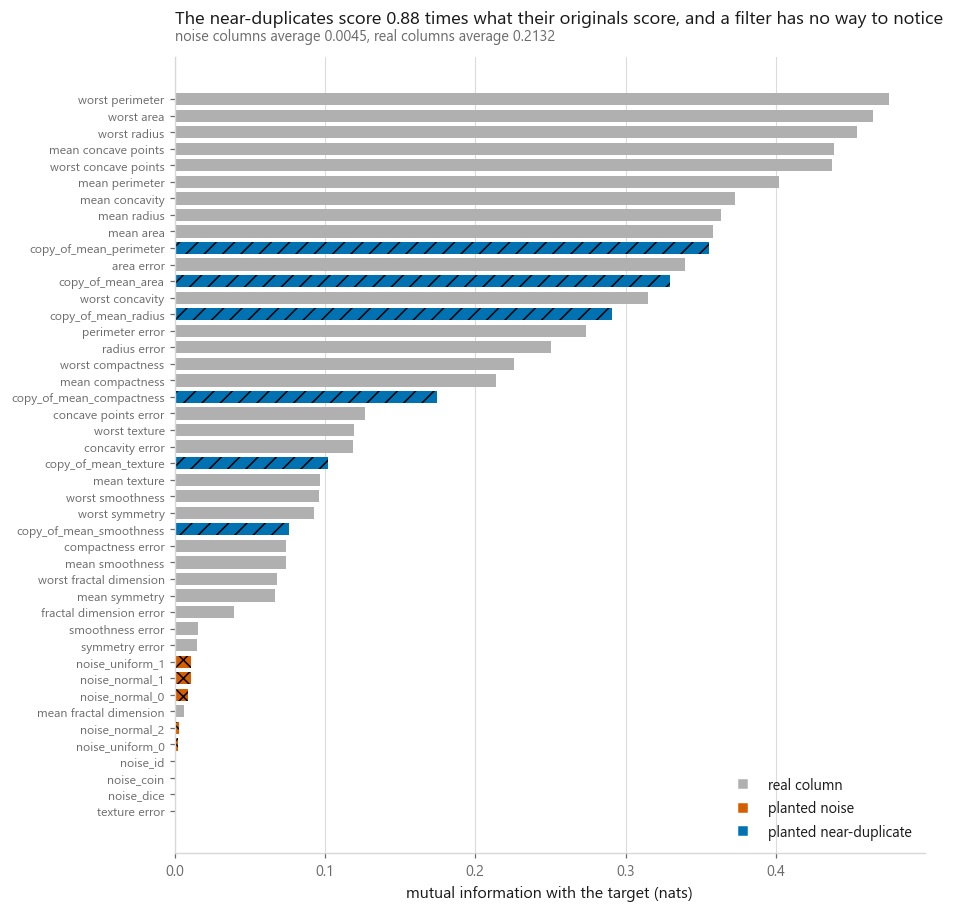

In [7]:
mi_rank = pd.Series(theirs, index=columns).sort_values()
colours = [{"real": style.NEUTRAL, "noise": style.HIGHLIGHT,
            "copy": style.PALETTE[0]}[group[c]] for c in mi_rank.index]
hatches = [{"real": "", "noise": "xx", "copy": "//"}[group[c]] for c in mi_rank.index]

fig, ax = plt.subplots(figsize=(8.8, 9.4))
bars = ax.barh(range(len(mi_rank)), mi_rank.values, color=colours, height=0.74)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)
ax.set_yticks(range(len(mi_rank)), mi_rank.index, fontsize=8)
ax.set_xlabel("mutual information with the target (nats)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
handles = [plt.Line2D([], [], marker="s", ls="", color=c, label=lab)
           for lab, c in [("real column", style.NEUTRAL),
                          ("planted noise", style.HIGHLIGHT),
                          ("planted near-duplicate", style.PALETTE[0])]]
ax.legend(handles=handles, loc="lower right")

copy_scores = mi_rank[copy_columns]
original_scores = mi_rank[originals]
style.title(ax,
            f"The near-duplicates score {copy_scores.mean() / original_scores.mean():.2f} "
            f"times what their originals score, and a filter has no way to notice",
            f"noise columns average {mi_rank[noise_columns].mean():.4f}, "
            f"real columns average {mi_rank[real_columns].mean():.4f}")
style.save(fig, FIG / "fig-01-planted-columns.png")

That chart is the mechanism behind everything in the results table. A planted
copy scores essentially what its original scores, because it contains essentially
the same information. A filter sorts this list and takes the top of it. Nothing in
the sorting can see that two entries are the same fact twice.

The noise columns are down at the bottom, which is the good news for filters: pure
irrelevance is the easy case and mutual information handles it.

what each method actually kept

mutual information (filter)
  kept 15 columns, of which 3 were planted
  planted columns kept: copy_of_mean_radius, copy_of_mean_perimeter, copy_of_mean_area

chi-squared (filter)
  kept 15 columns, of which 3 were planted
  planted columns kept: copy_of_mean_radius, copy_of_mean_perimeter, copy_of_mean_area

ANOVA F (filter)
  kept 15 columns, of which 3 were planted
  planted columns kept: copy_of_mean_radius, copy_of_mean_perimeter, copy_of_mean_area

RFE, logistic (wrapper)
  kept 15 columns, of which 1 were planted
  planted columns kept: copy_of_mean_perimeter

L1 logistic (embedded)
  kept 15 columns, of which 2 were planted
  planted columns kept: noise_id, noise_uniform_1

forest importance (embedded)
  kept 15 columns, of which 3 were planted
  planted columns kept: copy_of_mean_radius, copy_of_mean_perimeter, copy_of_mean_area


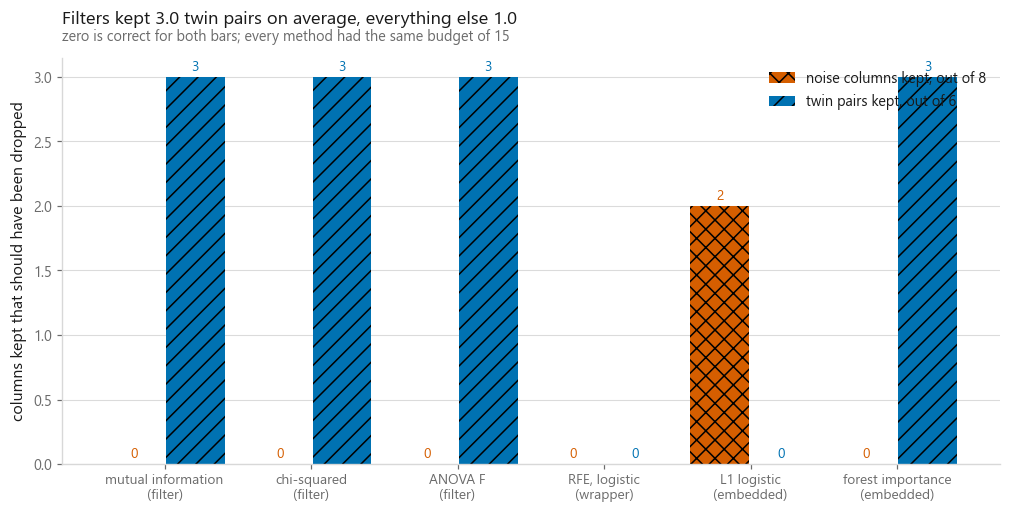

In [8]:
positions = np.arange(len(results))
fig, ax = plt.subplots(figsize=(11.0, 4.8))
ax.bar(positions - 0.21, results["noise kept"], width=0.4, color=style.HIGHLIGHT,
       hatch="xx", label=f"noise columns kept, out of {N_NOISE}")
ax.bar(positions + 0.21, results["twin pairs kept"], width=0.4, color=style.PALETTE[0],
       hatch="//", label=f"twin pairs kept, out of {N_REDUNDANT}")
for x, (a, b) in enumerate(zip(results["noise kept"], results["twin pairs kept"])):
    ax.annotate(f"{a}", xy=(x - 0.21, a), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, color=style.HIGHLIGHT)
    ax.annotate(f"{b}", xy=(x + 0.21, b), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, color=style.PALETTE[0])
ax.set_xticks(positions, [f"{m}\n({FAMILY[m]})" for m in results["method"]], fontsize=9)
ax.set_ylabel("columns kept that should have been dropped")
ax.legend(loc="upper right")
filters = results[results["family"] == "filter"]
others = results[results["family"] != "filter"]
style.title(ax,
            f"Filters kept {filters['twin pairs kept'].mean():.1f} twin pairs on average, "
            f"everything else {others['twin pairs kept'].mean():.1f}",
            f"zero is correct for both bars; every method had the same budget of {K}")
style.save(fig, FIG / "fig-02-what-was-kept.png")

print("what each method actually kept")
for name in METHODS:
    chosen = selections[name]
    junk = [c for c in chosen if group[c] != "real"]
    print(f"\n{name} ({FAMILY[name]})")
    print(f"  kept {len(chosen)} columns, of which {len(junk)} were planted")
    if junk:
        print(f"  planted columns kept: {', '.join(junk)}")

### The cost, in seconds

The structural argument is that a wrapper fits the model once per feature
removed and a filter fits it zero times. The printed seconds are the empirical
version of that on a dataset small enough to hide it.

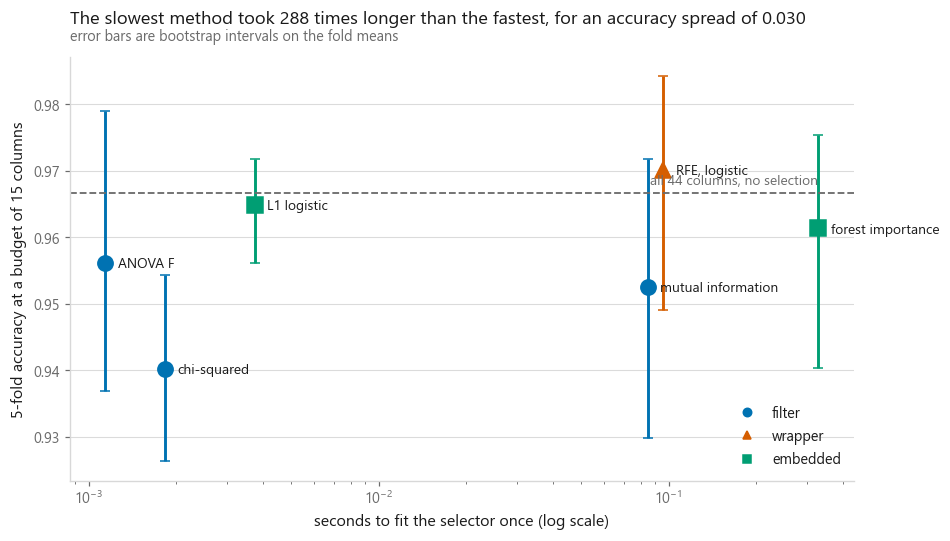

In [9]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))
markers = {"filter": "o", "wrapper": "^", "embedded": "s"}
family_colour = {"filter": style.PALETTE[0], "wrapper": style.HIGHLIGHT,
                 "embedded": style.PALETTE[2]}
for _, row in results.iterrows():
    ax.errorbar(row["seconds"], row["accuracy"],
                yerr=[[row["accuracy"] - row["low"]], [row["high"] - row["accuracy"]]],
                marker=markers[row["family"]], markersize=10,
                color=family_colour[row["family"]], capsize=3, ls="")
    ax.annotate(row["method"], xy=(row["seconds"], row["accuracy"]),
                xytext=(8, -3), textcoords="offset points", fontsize=9,
                color=style.INK)
ax.axhline(all_scores.mean(), color=style.MUTED, ls="--", lw=1.2)
ax.annotate(f"all {len(columns)} columns, no selection", xy=(results['seconds'].max(),
                                                             all_scores.mean()),
            xytext=(0, 6), textcoords="offset points", ha="right", fontsize=9,
            color=style.MUTED)
ax.set_xscale("log")
ax.set_xlabel("seconds to fit the selector once (log scale)")
ax.set_ylabel(f"5-fold accuracy at a budget of {K} columns")
handles = [plt.Line2D([], [], marker=m, ls="", color=family_colour[f], label=f)
           for f, m in markers.items()]
ax.legend(handles=handles, loc="lower right")
ratio = results["seconds"].max() / max(results["seconds"].min(), 1e-9)
style.title(ax,
            f"The slowest method took {ratio:.0f} times longer than the fastest, "
            f"for an accuracy spread of {results['accuracy'].max() - results['accuracy'].min():.3f}",
            "error bars are bootstrap intervals on the fold means")
style.save(fig, FIG / "fig-03-accuracy-vs-cost.png")

### How the cost scales

Seconds on a 569-row dataset are not the number a reader needs. What matters is
the shape of the curve as columns are added, because that is what decides whether
a wrapper is usable on your data.

 columns  mutual information  RFE, logistic  forest importance
      44               0.084          0.101              0.320
      64               0.127          0.170              0.321
      94               0.208          0.254              0.320
     144               0.284          0.429              0.312


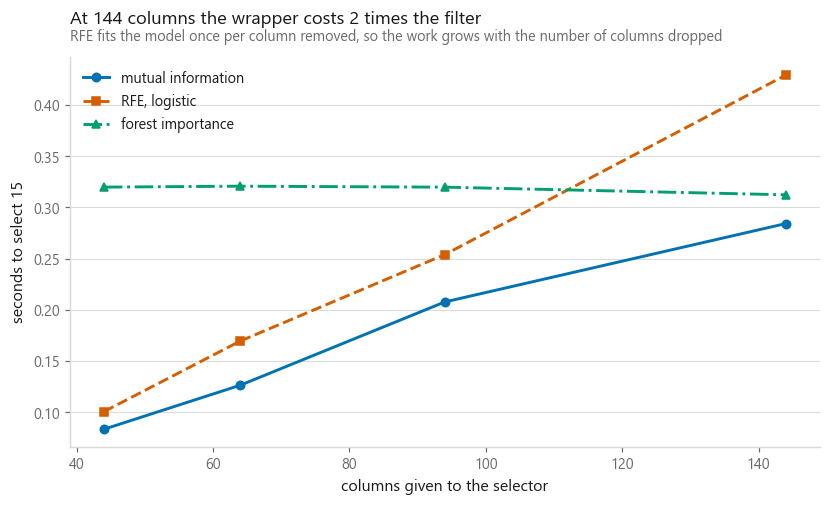

In [10]:
extra_widths = [0, 20, 50, 100]
scaling = []
scale_rng = np.random.default_rng(SEED + 1)

for extra in extra_widths:
    if extra:
        pad = pd.DataFrame(scale_rng.normal(size=(n, extra)),
                           columns=[f"pad_{i}" for i in range(extra)], index=X.index)
        X_wide = pd.concat([X, pad], axis=1)
    else:
        X_wide = X
    wide = X_wide.to_numpy()

    row = {"columns": X_wide.shape[1]}
    for name in ["mutual information", "RFE, logistic", "forest importance"]:
        pipeline = make_pipeline(*selector_steps(name, K))
        start = time.perf_counter()
        pipeline.fit(wide, y_values)
        row[name] = time.perf_counter() - start
    scaling.append(row)

scaling = pd.DataFrame(scaling)
print(scaling.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(figsize=(8.8, 4.6))
for i, name in enumerate(["mutual information", "RFE, logistic", "forest importance"]):
    ax.plot(scaling["columns"], scaling[name], marker=style.MARKERS[i],
            ls=style.DASHES[i], color=[style.PALETTE[0], style.HIGHLIGHT,
                                       style.PALETTE[2]][i], label=name)
ax.set_xlabel("columns given to the selector")
ax.set_ylabel(f"seconds to select {K}")
ax.legend(loc="upper left")
widest = scaling.iloc[-1]
style.title(ax,
            f"At {widest['columns']:.0f} columns the wrapper costs "
            f"{widest['RFE, logistic'] / widest['mutual information']:.0f} times the filter",
            f"RFE fits the model once per column removed, so the work grows with the "
            f"number of columns dropped")
style.save(fig, FIG / "fig-04-cost-scaling.png")

### Does the budget change the ranking?

A single budget is one point on a curve. Here is the curve.

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

method  ANOVA F  L1 logistic  RFE, logistic  chi-squared  forest importance  mutual information
budget                                                                                         
5        0.9473       0.9578         0.9684       0.9385             0.9473              0.9473
10       0.9508       0.9719         0.9649       0.9385             0.9543              0.9491
15       0.9561       0.9649         0.9701       0.9403             0.9613              0.9526
20       0.9736       0.9684         0.9701       0.9561             0.9666              0.9649
30       0.9789       0.9631         0.9701       0.9666             0.9824              0.9789


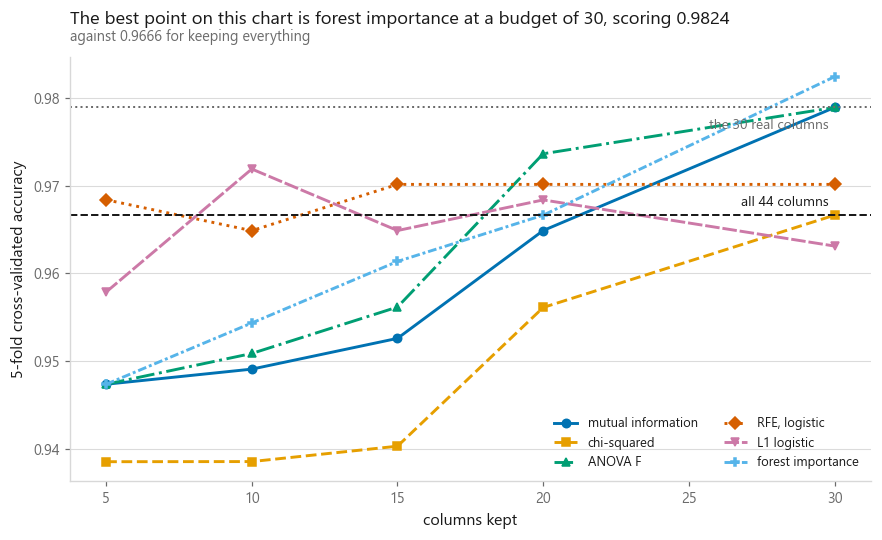

In [11]:
budgets = [5, 10, 15, 20, 30]
curve = []
for name in METHODS:
    for k in budgets:
        curve.append({"method": name, "budget": k, "accuracy": cv_folds(name, k).mean()})
curve = pd.DataFrame(curve)

fig, ax = plt.subplots(figsize=(9.4, 5.0))
for i, name in enumerate(METHODS):
    part = curve[curve["method"] == name]
    ax.plot(part["budget"], part["accuracy"], marker=style.MARKERS[i],
            ls=style.DASHES[i % len(style.DASHES)], color=style.PALETTE[i], label=name)
ax.axhline(all_scores.mean(), color=style.INK, ls="--", lw=1.3)
ax.annotate(f"all {len(columns)} columns", xy=(budgets[-1], all_scores.mean()),
            xytext=(-4, 6), textcoords="offset points", ha="right", fontsize=9,
            color=style.INK)
ax.axhline(oracle_scores.mean(), color=style.MUTED, ls=":", lw=1.3)
ax.annotate(f"the {len(real_columns)} real columns", xy=(budgets[-1], oracle_scores.mean()),
            xytext=(-4, -14), textcoords="offset points", ha="right", fontsize=9,
            color=style.MUTED)
ax.set_xlabel("columns kept")
ax.set_ylabel("5-fold cross-validated accuracy")
ax.legend(loc="lower right", fontsize=8.5, ncol=2)
peak = curve.loc[curve["accuracy"].idxmax()]
style.title(ax,
            f"The best point on this chart is {peak['method']} at a budget of "
            f"{peak['budget']:.0f}, scoring {peak['accuracy']:.4f}",
            f"against {all_scores.mean():.4f} for keeping everything")
style.save(fig, FIG / "fig-05-budget-curve.png")

print(curve.pivot(index="budget", columns="method", values="accuracy").round(4).to_string())

### How much does selecting outside the fold flatter you?

One more measurement, because it is the mistake that makes feature selection
look better than it is. Everything above put the selector inside the pipeline.
Here the selector is fitted once on the whole dataset, and only then is the model
cross-validated on the columns it chose.

In [12]:
honest = cv_folds("mutual information", K)

leaky_columns = selections["mutual information"]
leaky = cross_val_score(make_pipeline(StandardScaler(),
                                      LogisticRegression(max_iter=5000, random_state=SEED)),
                        X[leaky_columns].to_numpy(), y_values, cv=folds)

print(f"selector inside the folds  : {honest.mean():.4f}")
print(f"selector fitted on all data: {leaky.mean():.4f}")
print(f"the leak is worth          : {leaky.mean() - honest.mean():+.4f}")
gap, gap_low, gap_high = evaluate.paired_ci(leaky, honest, seed=SEED)
print(f"paired interval on that gap: [{gap_low:+.4f}, {gap_high:+.4f}]")
print("\nthe selector saw every row of every test fold before choosing, "
      "so this comparison is rigged in the leaky version's favour by construction")

selector inside the folds  : 0.9526
selector fitted on all data: 0.9508
the leak is worth          : -0.0018
paired interval on that gap: [-0.0053, +0.0000]

the selector saw every row of every test fold before choosing, so this comparison is rigged in the leaky version's favour by construction


Whatever size that gap came out, the reason to avoid the leak does not depend on
it being large. The leaky number is not an estimate of anything, because the
procedure it describes cannot be run on data you have not collected yet. See
[12-03](../../12-putting-it-together/03-pipelines/) for the general version of
this argument.

## Cheat sheet

| | |
|---|---|
| **Filter** | Cheapest by a wide margin, model-agnostic, and blind to redundancy by construction. Good as a first pass to cut a very wide table down to something a wrapper can chew |
| **Wrapper (RFE)** | Sees features together, so it can drop one of a duplicated pair. Costs one model fit per column removed, times folds if cross-validated |
| **Embedded (L1)** | Selection for free during fitting. Needs scaled features, needs its penalty tuned, and with correlated columns it picks one of the group somewhat arbitrarily |
| **Embedded (trees)** | Free and biased toward high-cardinality columns, as [12-02](../../12-putting-it-together/02-interpreting-models/) measures. Check the columns it kept, since the scores alone will not tell you |
| **chi-squared** | Non-negative input only, so scale to `[0, 1]` first. It is a test of independence, not a measure of strength |
| **Always** | Put the selector inside the cross-validation pipeline. Report what was kept, not only the accuracy |
| **Next** | [The perceptron](../../07-neural-networks/01-the-perceptron/), which starts part 7 |

## What to remember

1. Plant the answer key. Noise columns and near-duplicate columns turn feature
   selection from an opinion into a measurement, and they cost almost nothing
   to add.
2. Filters score one column at a time. Two columns saying the same thing get two
   good scores, and no filter can see the problem.
3. Accuracy at a fixed budget is a poor way to compare selectors. Compare what
   they kept, and put an error bar on the accuracy before reading anything into
   the ordering.
4. The wrapper's cost is one model fit per column dropped, and it grows with the
   width of the table. The scaling chart is the number to quote, not the seconds.
5. Impurity-based selection inherits the bias [12-02](../../12-putting-it-together/02-interpreting-models/)
   measured. Whether the bias is big enough to waste budget is a separate question,
   and the table in section 5 answers it for this dataset.
6. Selecting features outside the cross-validation folds produces a number that
   describes a procedure you cannot repeat on new data.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [07-01 The perceptron](../../07-neural-networks/01-the-perceptron/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#FeatureSelection` `#MutualInformation` `#RFE` `#Lasso`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#DimensionalityReduction`